In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
true_time=netCDF['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);

#Restricts the timesteps of the data from timesteps0 to 140
data=netCDF.isel(time=np.arange(0,140+1))
parcel=parcel.isel(time=np.arange(0,140+1))
res='1km'

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [ ]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [19]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
with h5py.File(dir2+'lagrangian_binary_array.h5', 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]

    # W = f['W'][:]
    # QCQI = f['QCQI'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)

In [ ]:
################################################################################

In [2]:
#OUT_NZ

# out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***


out=xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
save=xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

out_nz=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_nz[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_nz[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_nz[:,0] == elem)[0] 
    extras=idx[np.where(out_nz[idx,5]!=np.min(out_nz[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_nz), dtype=bool); mask[lst] = False
out_nz=out_nz[mask]; 
###############################################################################

out_nz=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];print('list of first 10 ignored parcels');print(save_nz[:5])
placeholder=out_nz.copy(); run=True
############################################################
print(f'there are a total of {len(out_nz)} CL parcels and {len(save_nz)} nonCL parcels')


ALL_out_nz=out_nz.copy(); ALL_save_nz=save_nz.copy()

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
list of first 10 ignored parcels
[[34 302 76 0.7418956298828125 34 37]
 [246 338 77 0.33685012817382814 2 11]
 [365 357 3 0.658669677734375 115 121]
 [363 440 62 0.18019241333007813 6 14]
 [483 465 43 0.2835696716308594 27 33]]
there are a total of 2088 CL parcels and 1717 nonCL parcels


In [6]:
def find_SBZ_xmaxs():
    # Define the directory and file path
    dir2 = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
    file_path = dir2 + 'Variable_Calculation/' + 'Convergence' + f'_{res}' + '.h5'
    
    # Open the HDF5 file in read mode
    with h5py.File(file_path, 'r') as f:
        # Access the 'conv' dataset
        conv_dataset = f['conv']
        
        # Define the vertical level you are interested in
        zlev = 4
        
        # Initialize a list to store the xmaxs for each time step
        xmaxs_list = []

        # Loop over each time step (axis=0 corresponds to time)
        for t in range(conv_dataset.shape[0]):  # conv_dataset.shape[0] is the time dimension size
            # Read the relevant slice for this time step and vertical level
            Conv_t_zlev = conv_dataset[t, zlev, :, :]  # Shape should be (y_size, x_size)
            
            # Calculate the mean across the y-axis
            Conv_ymean = np.mean(Conv_t_zlev, axis=0)  # Mean across the y-axis
            
            # Find the index of the maximum value along the x-axis
            xmax = np.argmax(Conv_ymean)
            
            # Append the result for this time step
            xmaxs_list.append(xmax)
    
    # Convert the list of xmaxs to a numpy array (optional)
    xmaxs = np.array(xmaxs_list)

    return xmaxs #returns SBZ x location for each timestep

SBZ_xmaxs=find_SBZ_xmaxs()

In [9]:
Ps=out_nz[:,0]
Ts=out_nz[:,4]

In [41]:
Coast_x=256
Coast_Lst=[]
SBZ_Lst=[]

kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1) #number of kms per grid
Position=(Ts,Ps)
for (t,p) in zip(*Position):
    Coast_Dist=X[t,p]-Coast_x
    Coast_Dist*=kms
    Coast_Lst.append(Coast_Dist)
    
    SBZ_Dist=X[t,p]-SBZ_xmaxs[t]
    SBZ_Dist*=kms
    SBZ_Lst.append(SBZ_Dist)

In [50]:
# plt.hist(SBZ_Lst,bins=300)
# plt.ylabel('count');plt.xlabel('X Distance (km)')
# plt.title('Distance from SBZ Front')
# plt.xlim((-256,256))

# plt.hist(Coast_Lst,bins=300)
# plt.ylabel('count');plt.xlabel('X Distance (km)')
# plt.title('Distance from Coast')
# plt.xlim((-256,256))

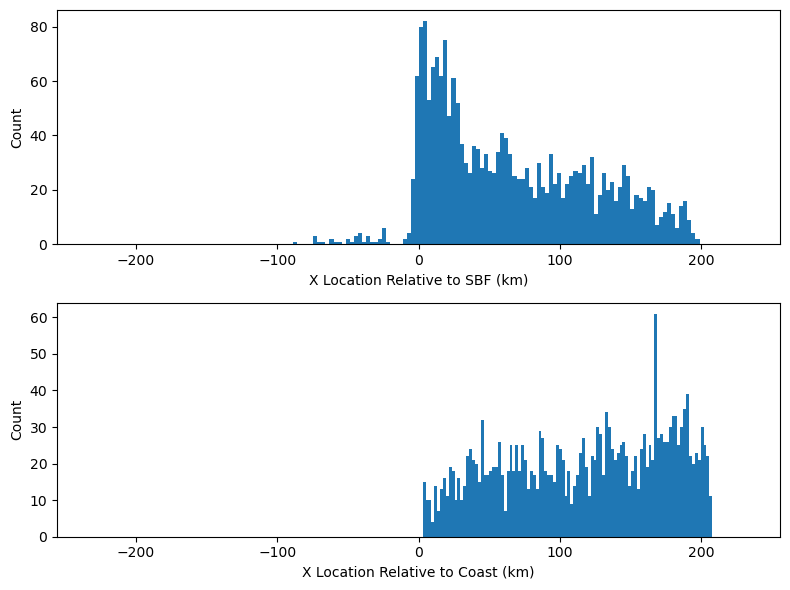

In [72]:
num_bins=100
# num_bins=10

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8, 6))  # Adjust figure size for a more rectangular layout
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])  # 2 rows, 1 column

# First subplot: Distance from SBZ Front
ax1 = plt.subplot(gs[0])
ax1.hist(SBZ_Lst, bins=num_bins)
ax1.set_ylabel('Count')
ax1.set_xlabel('X Location Relative to SBF (km)')
ax1.set_xlim((-256, 256))

# Second subplot: Distance from Coast
ax2 = plt.subplot(gs[1])
ax2.hist(Coast_Lst, bins=num_bins)
ax2.set_ylabel('Count')
ax2.set_xlabel('X Location Relative to Coast (km)')
ax2.set_xlim((-256, 256))


plt.suptitle('Histogram for the locations where tracked CI occurs')
plt.tight_layout()  # Adjust layout to prevent overlap

